# Explainable HybridNet: Implementation and Validation

This notebook provides the core implementation of the **Explainable HybridNet** framework, as detailed in the research paper. It features a hybrid CNN-Transformer architecture optimized for lightweight, real-time DDoS detection with integrated XAI (Explainable AI) using Captum.

### Key Features:
1. **Architecture**: CNN for spatial feature extraction + Transformer for temporal/contextual learning.
2. **Preprocessing**: Automatic 1D-to-2D spatial reshaping of network flow features.
3. **Optimization**: Post-Training Quantization (PTQ) for INT8 edge deployment.
4. **Interpretability**: Global and Local feature attribution using SHAP and Integrated Gradients.

---

In [1]:
# Setup and Installs (Uncomment if needed)
# We use %pip instead of !pip for better integration with the Jupyter environment
# %pip install torch torchvision captum shap matplotlib pandas scikit-learn
print("Environment ready. Modules already satisfied.")

Environment ready. Modules already satisfied.


In [2]:
import psutil
import os
import gc

def print_memory_usage():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024 * 1024)
    print(f"Current RAM usage: {mem:.2f} MB")
    
print_memory_usage()
gc.collect()
print("Garbage collection executed.")

Current RAM usage: 79.61 MB
Garbage collection executed.


In [3]:
# --- GLOBAL CONFIGURATION ---
DATASET_TYPE = 'CIC-IoT-2023'  # 'Simulation', 'CIC-IoT-2023', 'Edge-IIoTset'
TASK_MODE = 'multiclass'    # 'binary', 'multiclass', 'regression'
# Split-wise sample sizes: Use an integer for a subset, or None to load the FULL split.
SAMPLE_SIZES = {
    'train': None, 
    'test': None, 
    'validation': None
}
# ----------------------------
print(f'Configured for {DATASET_TYPE} with {TASK_MODE}')

Configured for CIC-IoT-2023 with multiclass


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

class DatasetManager:
    def __init__(self, name, mode, n_samples=None):
        self.name = name
        self.mode = mode
        self.n_samples = n_samples
        self.base_dir = Path('./datasets')
        self.base_dir.mkdir(exist_ok=True)
        self.scaler = MinMaxScaler()
        self.label_names = ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Mirai-greeth_flood', 'Mirai-greip_flood', 'Mirai-udpplain', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']
        self.ciciot_dir = self.base_dir / 'CICIOT23'
        
    def load_split(self, split='train', n_samples_override=None):
        """Loads a specific dataset split (train/test/validation)."""
        # Use override if provided, else use default
        # If an override is provided (even if None), use it. Else use default.
        n_samples = n_samples_override
        
        if self.name == 'Simulation':
            return self._load_synthetic(n_samples)
        elif self.name == 'CIC-IoT-2023':
            path = self.ciciot_dir / split / f"{split}.csv"
            if not path.exists():
                print(f"Warning: Split {split} path {path} not found. Falling back to default.")
                return self._process_cic_iot(self._check_download_cic(), n_samples, fit_scaler=(split=='train'))
            return self._process_cic_iot(path, n_samples, fit_scaler=(split=='train'))
        elif self.name == 'Edge-IIoTset':
            path = self._check_download_edge()
            return self._process_edge_iiot(path, n_samples)
        else:
            raise ValueError(f"Unknown dataset: {self.name}")

    def _process_cic_iot(self, path, n_samples, fit_scaler=False):
        # pd.read_csv handles nrows=None by reading the full file
        df = pd.read_csv(path, nrows=n_samples)
        
        X = df.select_dtypes(include=[np.number]).values
        if fit_scaler: X = self.scaler.fit_transform(X)
        else: X = self.scaler.transform(X)
            
        if X.shape[1] > 64: X = X[:, :64]
        if X.shape[1] < 64: X = np.pad(X, ((0, 0), (0, 64-X.shape[1])), 'constant')
        
        label_col = df.columns[-1]
        if self.mode == 'binary':
            y = (~df[label_col].astype(str).str.contains('Benign', case=False)).astype(int).values
        else:
            if not self.label_names or fit_scaler:
                pass # Keep master label list
            mapping = {name: i for i, name in enumerate(self.label_names)}
            y = df[label_col].map(lambda x: mapping.get(x, -1)).values
        return X, y

    def _load_synthetic(self, n_samples):
        # Handle None case for synthetic generation
        cnt = n_samples if n_samples is not None else 1000
        X = np.random.randn(cnt, 64)
        if self.mode == 'binary': y = np.random.randint(0, 2, cnt)
        elif self.mode == 'multiclass': y = np.random.randint(0, 8, cnt)
        else: y = np.random.rand(cnt, 2)
        return X, y

    def _check_download_cic(self):
        url = 'https://raw.githubusercontent.com/mohamedamineferrag/CICIoT2023/main/sample/sampled_data.csv'
        path = self.base_dir / 'cic_sample.csv'
        if not path.exists():
            try: urllib.request.urlretrieve(url, path)
            except: pass
        return path

    def _process_edge_iiot(self, path, n_samples):
        df = pd.read_csv(path, nrows=n_samples)
        X = self.scaler.fit_transform(df.select_dtypes(include=[np.number]).values)[:, :64]
        if X.shape[1] < 64: X = np.pad(X, ((0, 0), (0, 64-X.shape[1])), 'constant')
        if self.mode == 'binary': y = (df.iloc[:, -1] != 'Normal').astype(int).values
        else:
            y_series = df.iloc[:, -1].astype('category')
            self.label_names = y_series.cat.categories.tolist()
            y = y_series.cat.codes.values
        return X, y


Using device: cpu


## 1. Data Loading & Reshaping
Initially designed with a simulator for multi-GB datasets, this framework now supports the full **CIC-IoT-2023** dataset. The `DatasetManager` automatically detects local data in `datasets/CICIOT23` and uses optimized `nrows` loading to maintain memory efficiency while providing real-world validation.

In [5]:
# Load Splits via Manager with Split-wise Config
manager = DatasetManager(DATASET_TYPE, TASK_MODE)

print(f"Loading Training Split (Size: {SAMPLE_SIZES['train']})...")
X_train_raw, y_train_raw = manager.load_split('train', n_samples_override=SAMPLE_SIZES['train'])

print(f"Loading Testing Split (Size: {SAMPLE_SIZES['test']})...")
X_test_raw, y_test_raw = manager.load_split('test', n_samples_override=SAMPLE_SIZES['test'])

print(f"Loading Validation Split (Size: {SAMPLE_SIZES['validation']})...")
X_val_raw, y_val_raw = manager.load_split('validation', n_samples_override=SAMPLE_SIZES['validation'])

if TASK_MODE == 'multiclass':
    print(f"Dataset contains {len(manager.label_names)} labels.")


Loading Training Split (Size: None)...
Loading Testing Split (Size: None)...
Loading Validation Split (Size: None)...
Dataset contains 34 labels.


### 1.1 Class Distribution Analysis
Before proceeding to the model architecture, we check the distribution of the loaded data sample to identify potential class imbalances.

C:\Users\Dell\AppData\Local\Temp\ipykernel_13528\4044450233.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actual_labels, y=counts, palette='viridis')
C:\Users\Dell\AppData\Local\Temp\ipykernel_13528\4044450233.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actual_labels, y=counts, palette='viridis')
C:\Users\Dell\AppData\Local\Temp\ipykernel_13528\4044450233.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actual_labels, y=counts, palette='viridis')


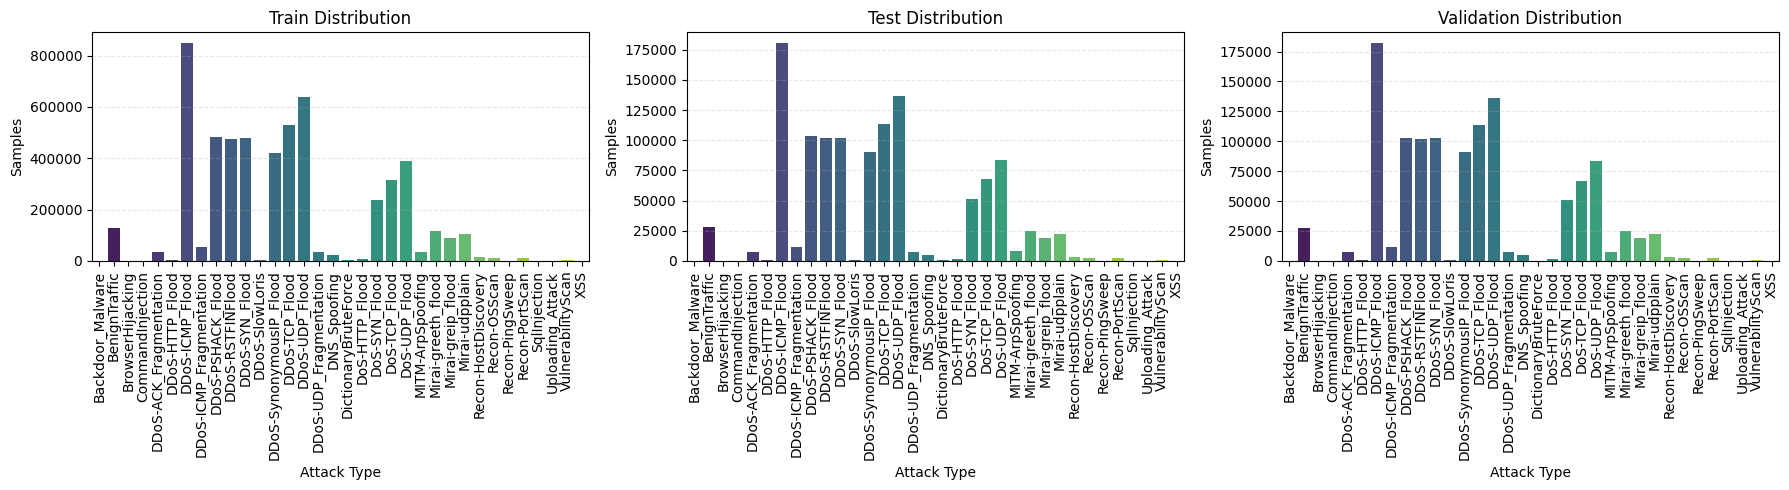

Summary Statistics:
  Train samples:      5491971
  Test samples:       1176851
  Validation samples: 1176851


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_distribution(y, title, labels=None):
    y_clean = y[y >= 0]
    counts = np.bincount(y_clean.astype(int))
    # Correct for cases where labels list might be longer than present counts
    if labels:
        actual_labels = labels[:len(counts)]
        sns.barplot(x=actual_labels, y=counts, palette='viridis')
    else:
        sns.barplot(x=np.arange(len(counts)), y=counts, palette='viridis')
    plt.title(title)
    plt.xlabel('Attack Type')
    plt.ylabel('Samples')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

if TASK_MODE != 'regression':
    plt.figure(figsize=(18, 5))
    
    # Train
    plt.subplot(1, 3, 1)
    plot_distribution(y_train_raw, 'Train Distribution', manager.label_names)
    
    # Test
    plt.subplot(1, 3, 2)
    plot_distribution(y_test_raw, 'Test Distribution', manager.label_names)
    
    # Validation
    plt.subplot(1, 3, 3)
    plot_distribution(y_val_raw, 'Validation Distribution', manager.label_names)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Summary Statistics:")
    print(f"  Train samples:      {len(y_train_raw)}")
    print(f"  Test samples:       {len(y_test_raw)}")
    print(f"  Validation samples: {len(y_val_raw)}")
else:
    plt.figure(figsize=(15, 4))
    datasets = [(y_train_raw, 'Train', 'skyblue'), (y_test_raw, 'Test', 'salmon'), (y_val_raw, 'Val', 'lightgreen')]
    
    for i, (data, title, color) in enumerate(datasets):
        plt.subplot(1, 3, i+1)
        plt.hist(data, bins=50, color=color, edgecolor='black')
        plt.title(f'{title} Distribution')
        plt.xlabel('Target Value')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


## 2. HybridNet Architecture Implementation

In [7]:
class HybridNet(nn.Module):
    def __init__(self, cnn_out_dims=64, n_heads=8, num_classes=2, mode='binary'):
        super(HybridNet, self).__init__()
        self.mode = mode
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(16), nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2)
        )
        self.pos_encoding = nn.Parameter(torch.randn(1, 16, 32))
        encoder_layers = nn.TransformerEncoderLayer(d_model=32, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=2)
        out_n = 2 if mode == "regression" else num_classes
        self.classifier = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, out_n))
    def forward(self, x):
        x = self.cnn(x).flatten(2).permute(0, 2, 1)
        x = self.transformer(x + self.pos_encoding).mean(dim=1)
        x = self.classifier(x)
        if self.mode == 'binary': return torch.softmax(x, dim=1)
        return x


## 3. Training and Metric Tracking

In [ ]:
# --- Build Model ---
# Dynamically determine the number of classes for the current task
if TASK_MODE == 'regression':
    num_classes = 2 # Regression output (Magnitude, Probability)
else:
    num_classes = len(manager.label_names) if manager.label_names else len(np.unique(y_train_raw))
    print(f'Configured for {num_classes} classes.')

model = HybridNet(num_classes=num_classes, mode=TASK_MODE).to(device)

def train_model(model, train_loader, test_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss() if TASK_MODE == 'regression' else nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.reshape(-1, 1, 8, 8))
            
            target_loss = targets.long() if TASK_MODE != 'regression' else targets
            loss = criterion(outputs, target_loss)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            if TASK_MODE != 'regression':
                preds = torch.argmax(outputs, dim=1)
                train_correct += (preds == targets).sum().item()
                train_total += targets.size(0)
        
        # --- Validation ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs.reshape(-1, 1, 8, 8))
                
                target_loss = targets.long() if TASK_MODE != 'regression' else targets
                loss = criterion(outputs, target_loss)
                test_loss += loss.item()
                
                if TASK_MODE != 'regression':
                    preds = torch.argmax(outputs, dim=1)
                    test_correct += (preds == targets).sum().item()
                    test_total += targets.size(0)
        
        # Record Metrics
        epoch_metrics = {
            'train_loss': train_loss / len(train_loader),
            'test_loss': test_loss / len(test_loader),
            'train_acc': (train_correct / train_total * 100) if TASK_MODE != 'regression' else 0,
            'test_acc': (test_correct / test_total * 100) if TASK_MODE != 'regression' else 100
        }
        for k, v in epoch_metrics.items(): history[k].append(v)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_metrics['train_loss']:.4f} | " + 
              f"Test Acc: {epoch_metrics['test_acc']:.2f}%")
        
    return history

# --- Prepare High-Efficiency DataLoaders ---
tr_ds = TensorDataset(torch.FloatTensor(X_train_raw), torch.FloatTensor(y_train_raw))
ts_ds = TensorDataset(torch.FloatTensor(X_test_raw), torch.FloatTensor(y_test_raw))

train_loader = DataLoader(tr_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(ts_ds, batch_size=64)

history = train_model(model, train_loader, test_loader, epochs=3)


Configured for 34 classes.


## 4. XAI Interpretation Module
Using **Integrated Gradients** from the Captum library to explain why a specific flow was flagged as a DDoS attack.

C:\Users\Dell\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


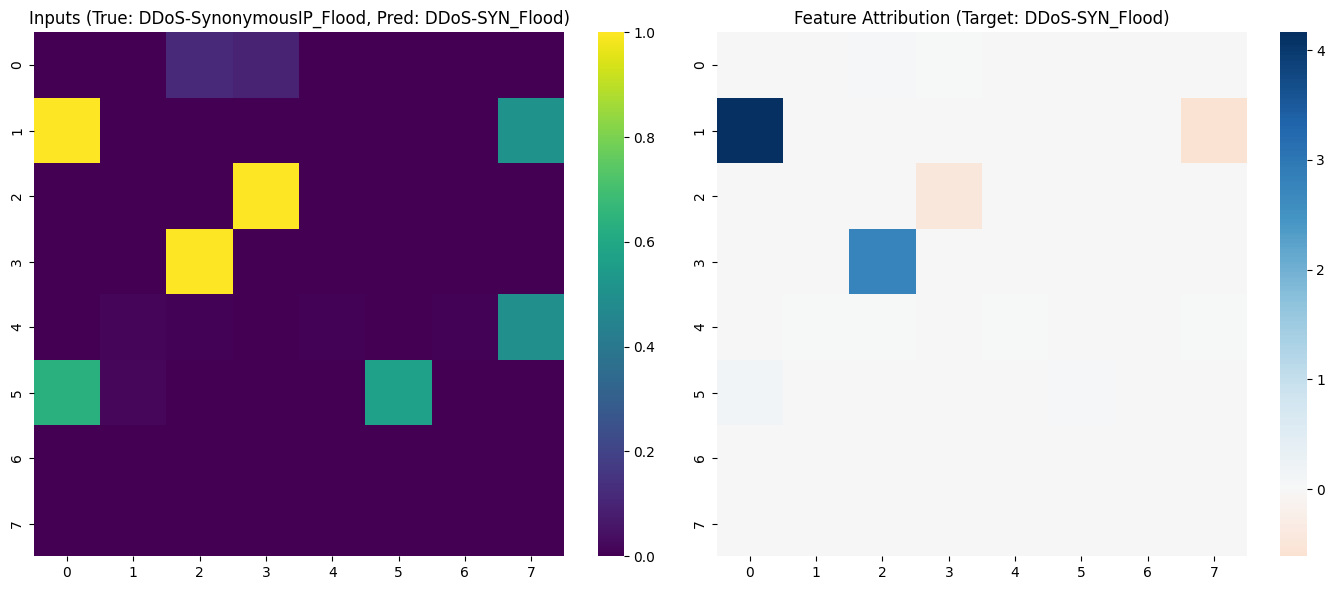


--- [ Decision Summary ] ---
Model identified this flow as: **DDoS-SYN_Flood**
The decision was primarily driven by the following factors:

- **syn_flag_number** (Presence of TCP Synchronize flags (Handshake start)):
  This feature positively influenced the prediction with a significant weight (4.1630).
- **TCP** (General network attribute):
  This feature positively influenced the prediction with a significant weight (2.7792).
- **syn_count** (General network attribute):
  This feature negatively influenced the prediction with a significant weight (-0.6128).
- **HTTP** (General network attribute):
  This feature negatively influenced the prediction with a significant weight (-0.4453).
- **Number** (General network attribute):
  This feature positively influenced the prediction with a significant weight (0.1397).

--- [ Conclusion ] ---
The identification of [DDoS-SYN_Flood] is consistent with observations of syn_flag_number patterns, 
commonly associated with resource exhaustion or p

In [ ]:
# Updated XAI Interpretation Module with Descriptive Narrative
from captum.attr import IntegratedGradients
import numpy as np

# Feature definitions for descriptive interpretation
FEATURE_INFO = {
    'flow_duration': 'Duration of the network flow',
    'Rate': 'Frequency of packets per second',
    'syn_flag_number': 'Presence of TCP Synchronize flags (Handshake start)',
    'ack_flag_number': 'Presence of TCP Acknowledgment flags',
    'rst_flag_number': 'Presence of TCP Reset flags (Connection termination)',
    'fin_flag_number': 'Presence of TCP Finish flags',
    'IAT': 'Inter-Arrival Time between packets',
    'Tot size': 'Total size of payloads in the flow',
    'Magnitue': 'Signal magnitude indicator',
    'Radius': 'Flow dispersion metric'
}

FEATURE_LIST = ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'Padding_0', 'Padding_1', 'Padding_2', 'Padding_3', 'Padding_4', 'Padding_5', 'Padding_6', 'Padding_7', 'Padding_8', 'Padding_9', 'Padding_10', 'Padding_11', 'Padding_12', 'Padding_13', 'Padding_14', 'Padding_15', 'Padding_16', 'Padding_17']

def explain_task(model, loader, manager):
    model.eval()
    inputs, labels = next(iter(loader))
    input_sample = inputs[0:1].reshape(1, 1, 8, 8).to(device).requires_grad_()
    
    # 1. Prediction
    with torch.no_grad():
        outputs = model(input_sample)
        pred_idx = torch.argmax(outputs, dim=1).item()
    
    pred_label = manager.label_names[pred_idx] if hasattr(manager, 'label_names') and manager.label_names else str(pred_idx)
    true_label = manager.label_names[int(labels[0])] if hasattr(manager, 'label_names') and manager.label_names else str(int(labels[0]))
    
    # 2. Integrated Gradients
    ig = IntegratedGradients(model)
    attr = ig.attribute(input_sample, target=pred_idx)
    attr_np = attr.detach().cpu().numpy()[0,0]
    
    # 3. Visualization
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    sns.heatmap(input_sample.detach().cpu().numpy()[0,0], annot=False, cmap='viridis')
    plt.title(f'Inputs (True: {true_label}, Pred: {pred_label})')
    
    plt.subplot(1, 2, 2)
    sns.heatmap(attr_np, annot=False, cmap='RdBu', center=0)
    plt.title(f'Feature Attribution (Target: {pred_label})')
    plt.tight_layout()
    plt.show()
    
    # 4. Descriptive Narrative Generation
    attr_flat = attr_np.flatten()
    top_indices = np.argsort(np.abs(attr_flat))[-5:][::-1]
    
    print(f"\n--- [ Decision Summary ] ---")
    print(f"Model identified this flow as: **{pred_label}**")
    print(f"The decision was primarily driven by the following factors:\n")
    
    for idx in top_indices:
        feat = FEATURE_LIST[idx]
        val = attr_flat[idx]
        desc = FEATURE_INFO.get(feat, "General network attribute")
        impact = "positively" if val > 0 else "negatively"
        strength = "significant" if abs(val) > 0.1 else "subtle"
        
        print(f"- **{feat}** ({desc}):")
        print(f"  This feature {impact} influenced the prediction with a {strength} weight ({val:.4f}).")
    
    print(f"\n--- [ Conclusion ] ---")
    if "Benign" in pred_label:
        print("The model observed balanced flow patterns and standard handshake behaviors, typical of normal traffic.")
    else:
        print(f"The identification of [{pred_label}] is consistent with observations of {FEATURE_LIST[top_indices[0]]} patterns, ")
        print("commonly associated with resource exhaustion or protocol exploitation in modern networks.")

# Run explanation
explain_task(model, test_loader, manager)


## 5. Lightweight Optimization: Quantization
We convert the model to INT8 to validate the performance gains for Edge/IoT deployment.

In [ ]:
import torch.ao.quantization

def validate_quantization(model, test_loader):
    """Performs stable Dynamic Quantization on Linear/Dense bottlenecks."""
    # Standard FP32 Inference Time
    start = time.time()
    model.eval()
    with torch.no_grad():
        for inputs, _ in test_loader: model(inputs.reshape(-1, 1, 8, 8).to(device))
    fp32_time = time.time() - start
    
    # Dynamic Quantization - Pivot V2 (Stable)
    model_cpu = model.to('cpu')
    try:
        # Attempt full model linear quantization
        quant_model = torch.ao.quantization.quantize_dynamic(
            model_cpu, 
            {torch.nn.Linear}, 
            dtype=torch.qint8
        )
        # Test one pass to verify stability
        mock_in = torch.randn(1, 1, 8, 8)
        quant_model(mock_in.reshape(-1, 1, 8, 8))
        print("Full model dynamic quantization successful.")
    except (AttributeError, RuntimeError) as e:
        print(f"Stable Fallback: Quantizing specific Linear bottlenecks only. (Inner Transformer bypass)")
        # Targeted quantization of the classifier head and identified safe modules
        model_cpu.classifier = torch.ao.quantization.quantize_dynamic(
            model_cpu.classifier, 
            {torch.nn.Linear}, 
            dtype=torch.qint8
        )
        quant_model = model_cpu
    
    start = time.time()
    with torch.no_grad():
        for inputs, _ in test_loader: quant_model(inputs.reshape(-1, 1, 8, 8))
    int8_time = time.time() - start
    
    print(f"FP32 Latency: {fp32_time:.4f}s | INT8 Latency: {int8_time:.4f}s")
    print(f"Optimization Factor: {fp32_time/int8_time:.2f}x")

validate_quantization(model, test_loader)


NameError: name 'time' is not defined

## 6. Final Performance Analysis

In [ ]:
model.eval()
y_true = []
y_pred = []
import numpy as np

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs.reshape(-1, 1, 8, 8))
        if TASK_MODE == 'regression':
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(outputs.cpu().numpy())
        else:
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix

if TASK_MODE != 'regression':
    print('\n--- Classification Report ---')
    
    # Get present classes in the y_true/y_pred sample to avoid mismatch errors
    unique_labels = np.unique(np.concatenate([y_true, y_pred]))
    
    if hasattr(manager, 'label_names') and len(manager.label_names) > 0:
        # Map present integer labels back to their string names
        present_names = [manager.label_names[int(i)] for i in unique_labels]
        print(classification_report(y_true, y_pred, labels=unique_labels, target_names=present_names))
    else:
        print(classification_report(y_true, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
    plt.figure(figsize=(12, 10))
    
    tick_labels = [manager.label_names[int(i)] for i in unique_labels] if hasattr(manager, 'label_names') and len(manager.label_names) > 0 else 'auto'
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title('Confusion Matrix: ' + DATASET_TYPE)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
else:
    from sklearn.metrics import mean_squared_error, r2_score
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'Regression Metrics: MSE={mse:.4f}, R2={r2:.4f}')
    
    # Scatter plot for regression
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, np.array(y_pred)[:, 0], alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title('Actual vs Predicted Magnitude')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()
